# **Bagging e Boosting**

## **Intuição**

Imagine que você está prestes a comprar um novo smartphone e encontra opções no mercado, cada uma com suas próprias especificações, recursos e preços.

Diante da diversidade de escolhas, você não tomaria uma decisão precipitada comprando o primeiro smartphone que vê.

Em vez disso, pesquisaria e analisaria diversos fatores para comprar o smatphone mais adequado e eficaz.

O mesmo acontece em Machine Learning, quando se trata de avaliar resultados de diversas fontes para obter um resultado final, utilizamos uma técnica chamada de `Ensemble`.

Os métodos `Ensemble` combinam as previsões de vários modelos de machine learning para obter resultados mais precisos e confiáveis.

## **Métodos Ensemble**

Um algoritmo que utiliza um conjunto de modelos diferentes ou variações do mesmo modelo com o objetivo de obter um modelo final com melhores resultados é chamado de método `Ensemble`.

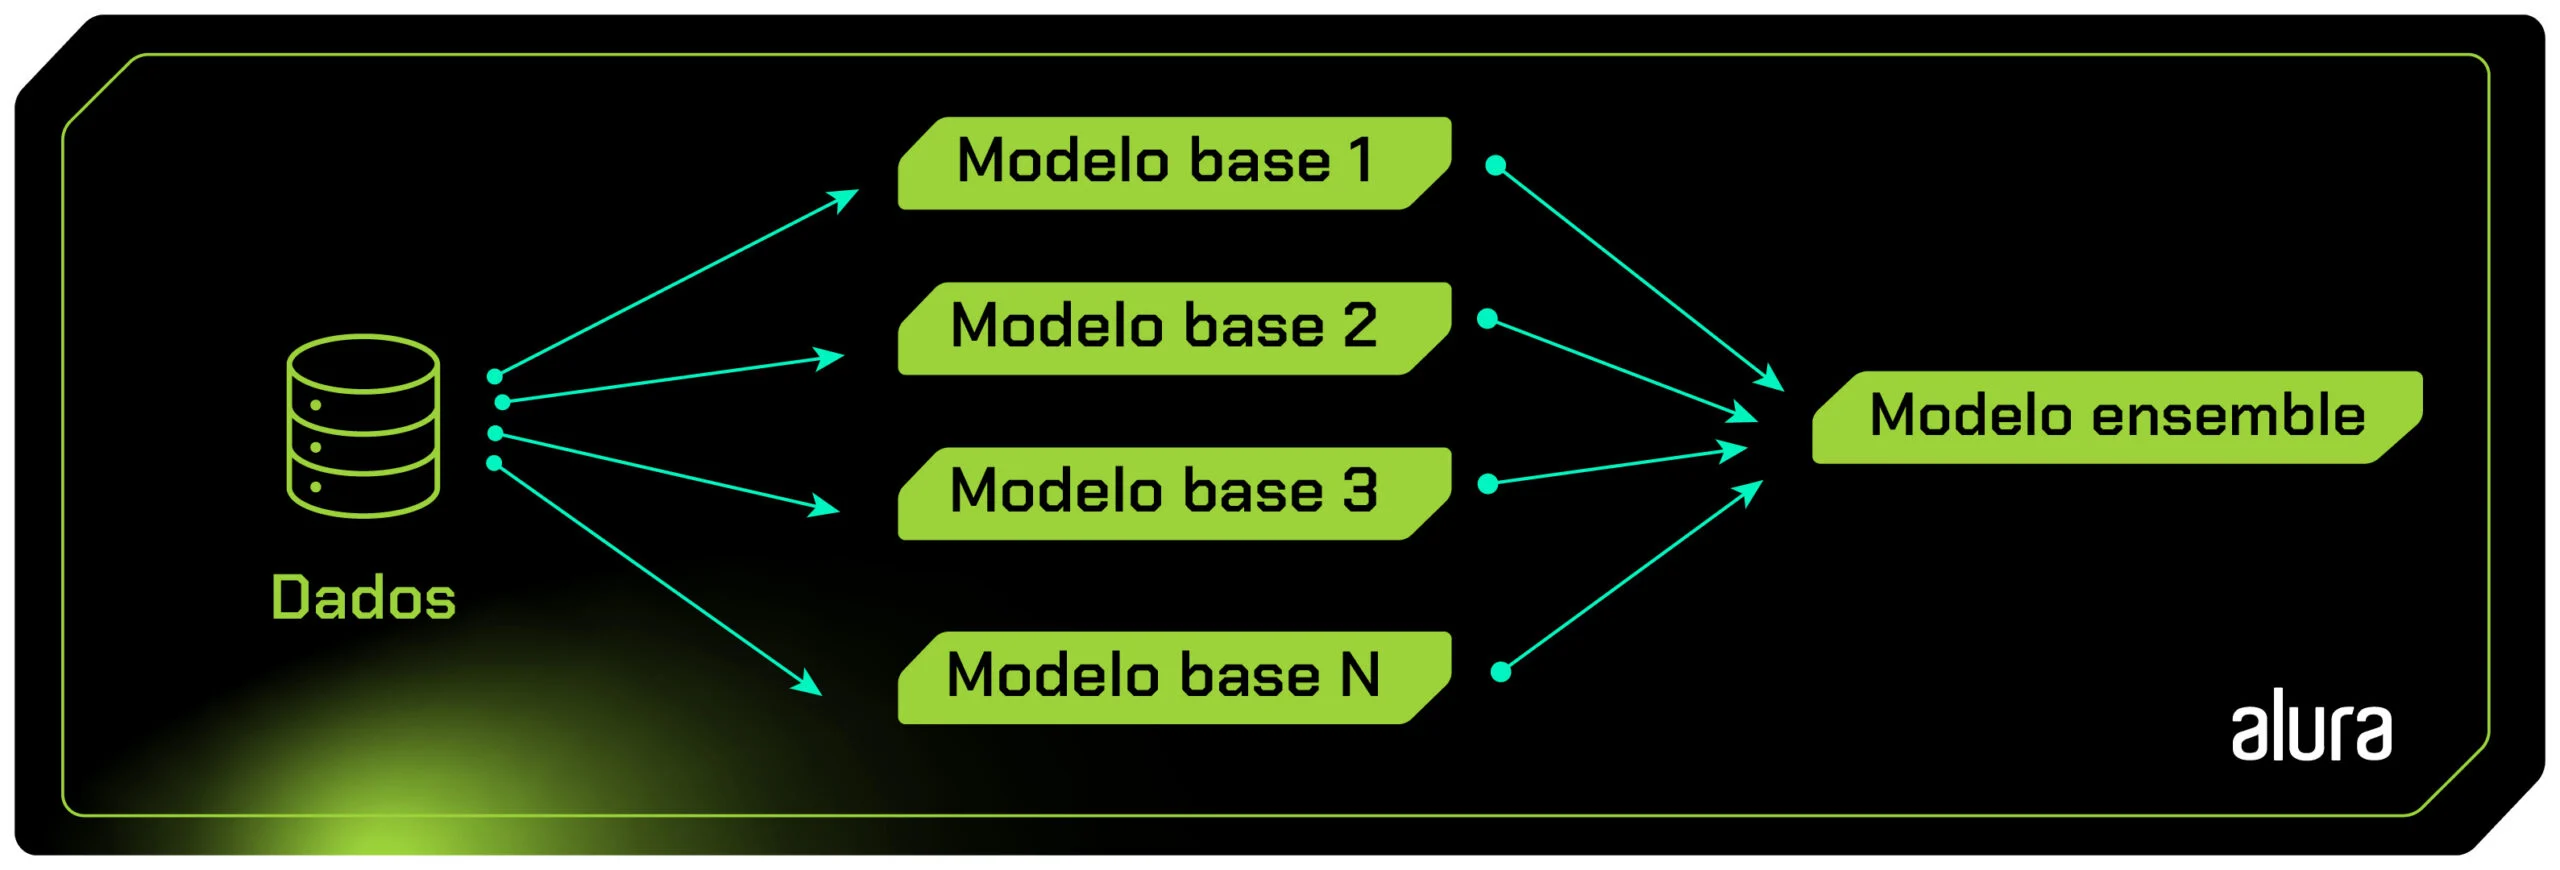

Ao tomar decisões importantes, é útil considerar diferentes pontos de vista.

Com isso, a ideia dos métodos `Ensemble` é combinar vários modelos base para obter um modelo final aprimorado.

O Objetivo é melhorar a precisão e generalização, reduzindo erros de **viés** e **variância**.

## **Bagging (Bootstrap Aggregating)**

Trata-se de uma técnica de `Ensemble` que visa reduzir a **variância** e, assim, evitar overfitting (quando o modelo decora os dados de treino e não generaliza bem para dados novos).

No `Bagging`, várias instâncias do mesmo algoritmo são treinadas paralelamente em subconjuntos aleatórios e independentes dos dados de treinamento. Esses subconjuntos são criados por meio de amostragem com reposição.

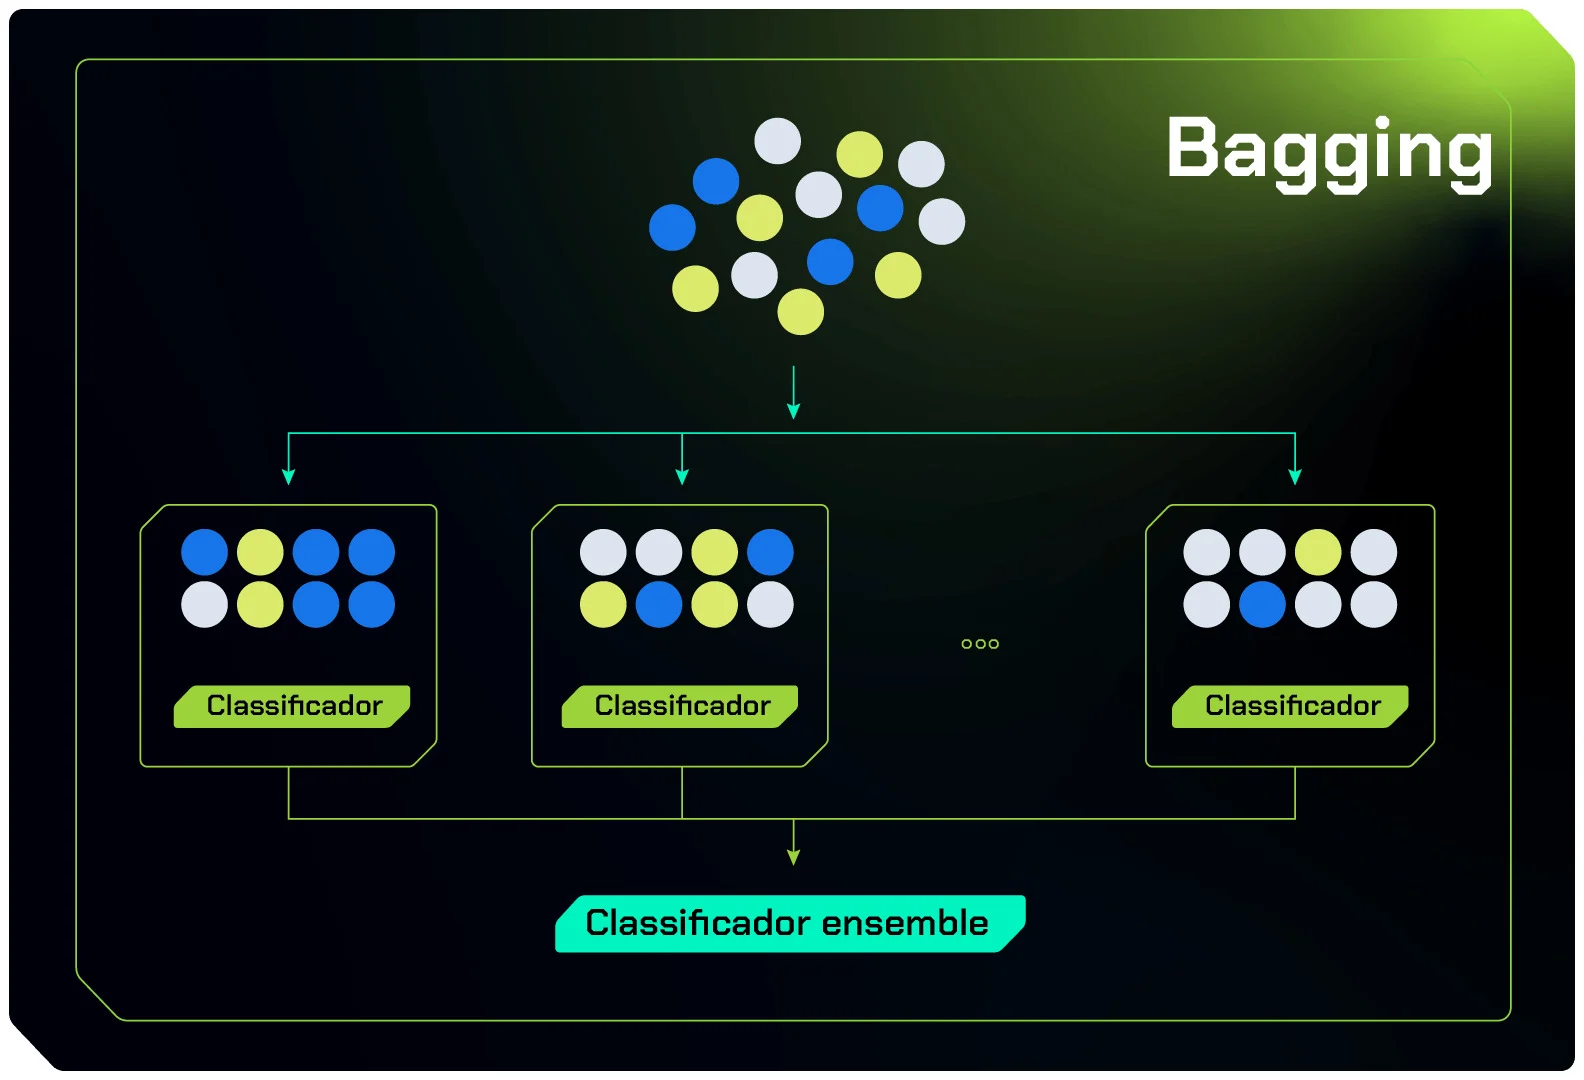

A decisão final é tomada por **votação majoritária** (em classificação) ou **média aritmética** (em regressão).

Um exemplo de algoritmo que faz uso  da técnica de Bagging é o *RandomForest*,  que utiliza conjuntos de árvores de decisão.

In [ ]:
# Importando bibliotecas

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score

In [16]:
# Carregando e Preparando os dados

X, y = load_digits(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

print(f'X_train shape = {X_train.shape}')
print(f'X_test shape = {X_test.shape}')
print(f'y_train shape = {y_train.shape}')
print(f'y_test shape = {y_test.shape}')

X_train shape = (1168, 64)
X_test shape = (629, 64)
y_train shape = (1168,)
y_test shape = (629,)


#### **Random Forests**
É uma variação do Bagging que aumenta a diversidade dos modelos treinados, sendo extremamente usado em ciência de dados.

Para isso, cada árvore na ensemble não terá acesso a todas as features. Em vez disso, nós selecionaremos, para aca uma, k features aleatórias, que serão as únicas visíveis para o modelo.

O valor de k é um hiperparâmetro, mas $\sqrt{N}$ é muitas vezes um bom valor inicial.

In [17]:
# Instânciando o modelo

model = RandomForestClassifier() # Configuração padrão

In [18]:
# Avaliação Inicial

scores = cross_val_score(model, X_train, y_train, cv=5)

print(f'Scores por folds: {scores}')
print(f'acurácia média = {scores.mean():.2%}')

Scores por folds: [0.95299145 0.94871795 0.97435897 0.98712446 0.97424893]
acurácia média = 96.75%


In [19]:
# Treinamento/Ajuste do modelo

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
# Predição e Avaliação

predict_ = model.predict(X_test)

acc = accuracy_score(y_test, predict_)

report = classification_report(y_test, predict_)

In [21]:
print(f'acc = {acc:.2%}')
print(f'Report: \n{report}')

acc = 97.62%
Report: 
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        57
           1       0.97      1.00      0.98        61
           2       1.00      1.00      1.00        57
           3       0.98      0.94      0.96        62
           4       0.97      1.00      0.99        66
           5       0.96      0.96      0.96        76
           6       0.98      0.98      0.98        59
           7       0.97      0.98      0.98        65
           8       0.98      0.96      0.97        55
           9       0.96      0.96      0.96        71

    accuracy                           0.98       629
   macro avg       0.98      0.98      0.98       629
weighted avg       0.98      0.98      0.98       629



## **Boosting**

Trata-se dos modelos base que são treinados de forma sequencial, em que cada modelo se concentra em corrigir o erro do modelo anterior. Para isso, o algoritmo atribui **pesos maiores** aos exemplos que foram classificados incorretamente nas etapas passadas.

O foco do `Boosting` é na redução do **viés**, sendo eficaz para corrigir modelos simples que não conseguem capturar padrões complexos (underfitting).

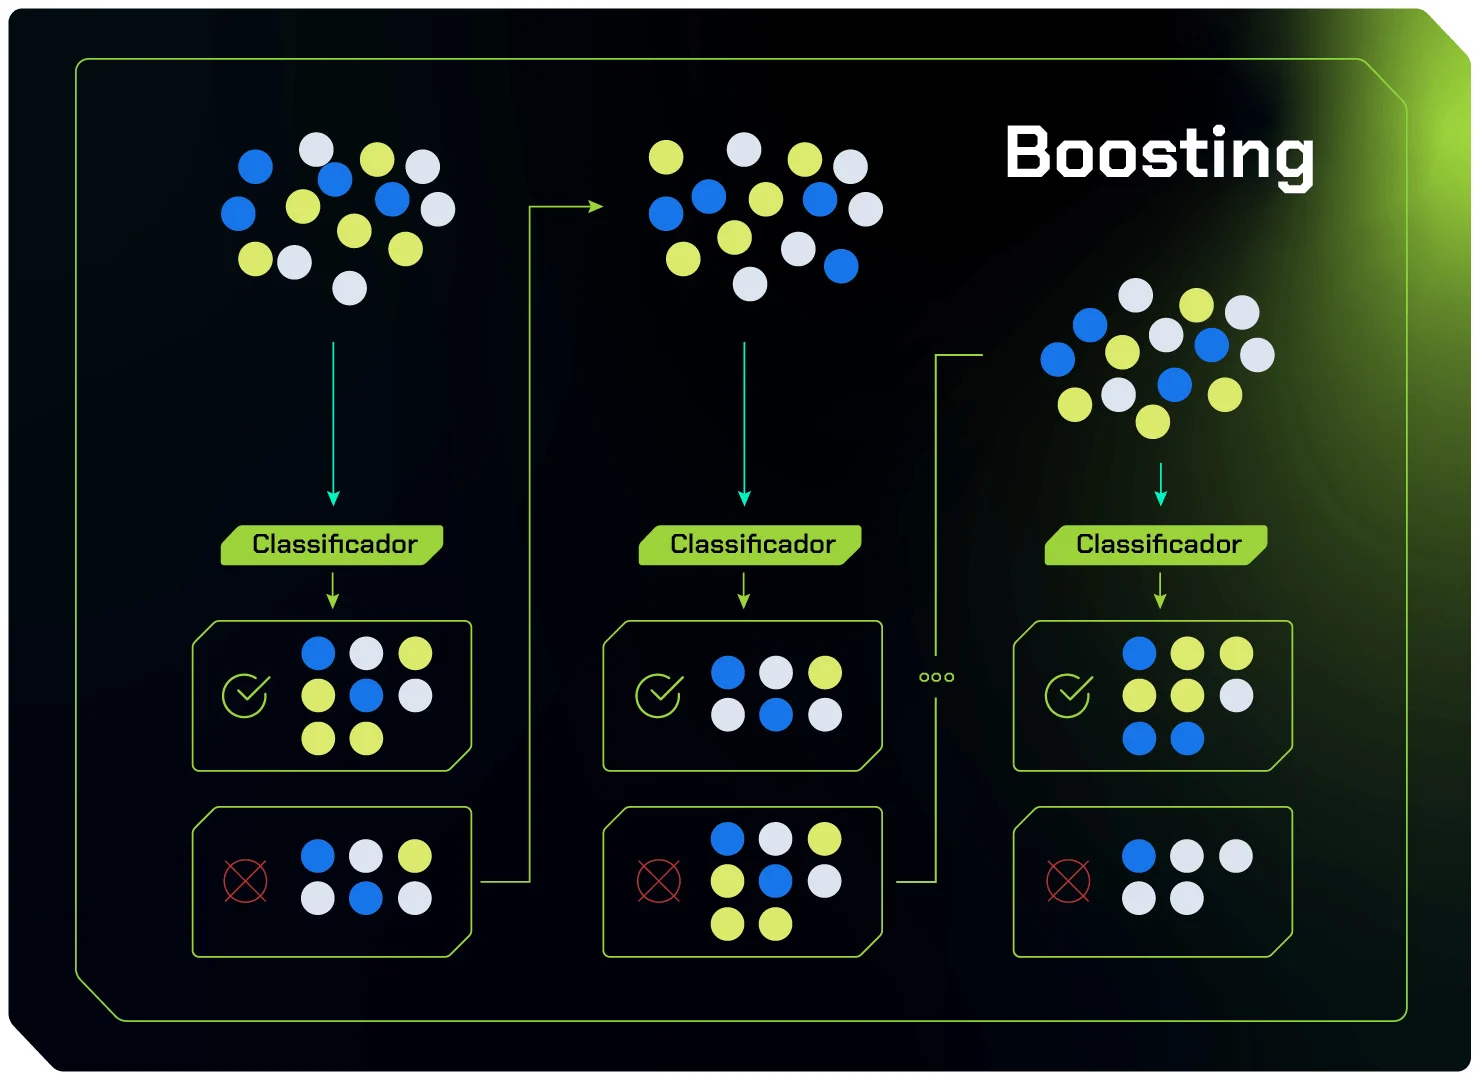

À medida que as iterações acontecem, o modelo `Ensemble` aprimora a sua capacidade de lidar melhor com os padrões complexos nos dados, resultando em uma melhora contínua no seu desempenho.

Um exemplo do `Boosting` é o *AdaBoost (Adaptative Boosting)*, que é um algoritmo que atribui pesos diferentes aos dados durante o treinamento. Ele começa treinando um modelo fraco e, em seguida, atribui pesos maiores aos exemplos classificados incorretamente pelo modelo fraco anterior.

In [22]:
# Importando bibliotecas

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

In [23]:
# Instânciando o modelo:  DecisionTreeClassifier

model_decision_tree = DecisionTreeClassifier(max_depth=5)

In [24]:
# Avaliação Inicial

scores_decision_tree = cross_val_score(model_decision_tree, X_train, y_train, cv = 5)

print(f'Scores por folds: {scores_decision_tree}')
print(f'acurácia média = {scores_decision_tree.mean():.2%}')

Scores por folds: [0.75641026 0.65811966 0.64102564 0.64806867 0.63519313]
acurácia média = 66.78%


In [25]:
# Criando o boost:

model_boost = AdaBoostClassifier(model_decision_tree, random_state=42)

In [26]:
# Treinando e Ajutando o modelo:

model_boost.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=5)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [27]:
# Predição e Avaliação

predict_ = model_boost.predict(X_test)

acc = accuracy_score(y_test, predict_)

report = classification_report(y_test, predict_)

In [28]:
print(f'acc = {acc:.2%}')
print(f'Report: \n{report}')

acc = 96.82%
Report: 
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        57
           1       0.92      0.95      0.94        61
           2       1.00      1.00      1.00        57
           3       0.97      0.95      0.96        62
           4       0.98      0.95      0.97        66
           5       0.97      0.97      0.97        76
           6       0.98      0.98      0.98        59
           7       0.97      0.98      0.98        65
           8       0.91      0.95      0.93        55
           9       0.97      0.96      0.96        71

    accuracy                           0.97       629
   macro avg       0.97      0.97      0.97       629
weighted avg       0.97      0.97      0.97       629



## **Principais Diferenças**

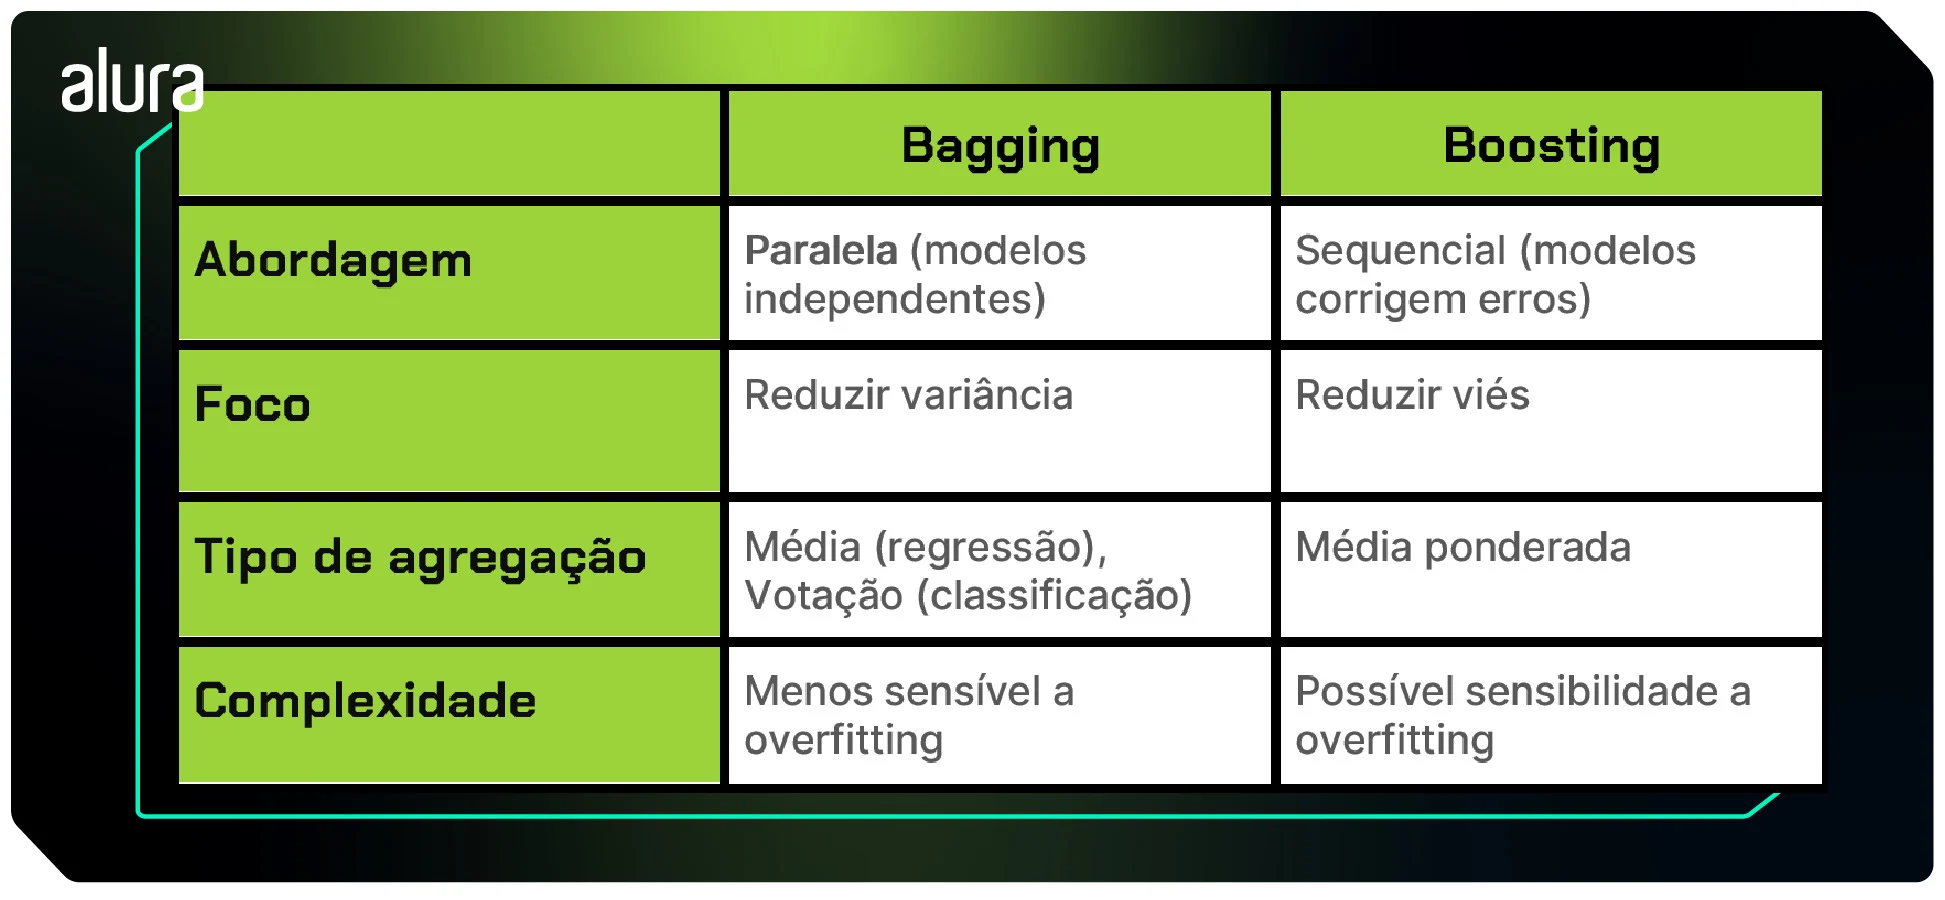

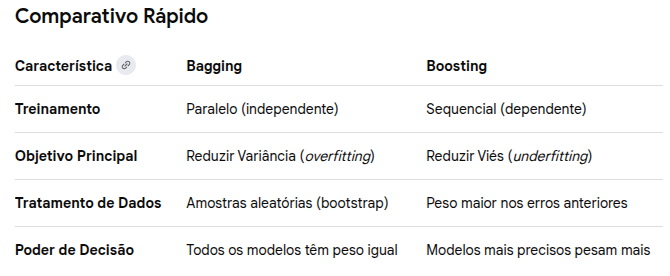

## **Referências**

- https://www.alura.com.br/artigos/machine-learning-tecnicas-bagging-boosting?srsltid=AfmBOopW7Ey1URxU2jobYPp7HWcpshNoCDkykjarCwmPT6lEFRb8TTdH
- https://medium.com/@8ugomes/diferen%C3%A7as-entre-bagging-and-boosting-em-ci%C3%AAncia-de-dados-ae5cd0f672ce